In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.metrics import confusion_matrix, accuracy_score
import os
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
stem = PorterStemmer().stem
import string
from scipy.sparse import csr_matrix

In [54]:
from scipy.sparse import hstack, vstack

In [2]:
for dirname, _, filenames in os.walk('./kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./kaggle/input\comment-category-prediction-challenge\Sample.csv
./kaggle/input\comment-category-prediction-challenge\test.csv
./kaggle/input\comment-category-prediction-challenge\train.csv


### EDA

In [3]:
df = pd.read_csv('./kaggle/input/comment-category-prediction-challenge/train.csv')

In [4]:
df.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

In [5]:
df['gender'].unique(), df['race'].unique(), df['religion'].unique()

(array([nan, 'none', 'male', 'female', 'transgender', 'other'],
       dtype=object),
 array([nan, 'none', 'white', 'other', 'asian', 'black', 'latino'],
       dtype=object),
 array([nan, 'christian', 'muslim', 'none', 'jewish', 'atheist', 'other',
        'hindu', 'buddhist'], dtype=object))

#### Null values Analysis
As comment is the most important feature here, the one row without comment can be dropped
As for race, gender, and religion, 'none' to be replaced with nan

In [6]:
df.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

In [7]:
df.if_1.sort_values().unique()

array([   0,    4,    5,    6,    7,    8,    9,   10,   11,   12,  249,
        250, 1232, 1254, 1256, 1257, 1258, 1263, 1267, 1271, 1277, 1538,
       1543, 1545, 1547, 1548, 1551, 1553, 1557, 1558, 1560, 1566, 1569,
       1572, 1576, 1581, 1583, 1584, 1585, 1767, 1777, 1778, 1783, 1800,
       1807, 1810, 1811, 1814, 1815, 1819, 1825, 1827, 1830, 1838, 1846,
       1848, 1860])

In [8]:
df['emoticon_1'].unique()

array([ 0,  1, 15,  2,  3,  4,  5, 11,  6,  7,  8, 24, 12, 17, 14, 13,  9,
       10, 20, 16, 25, 18, 21, 19, 23, 36, 22, 28, 27, 33, 30, 46, 32, 47,
       31, 39])

In [9]:
pd.concat([pd.get_dummies(df['label']).astype(int),df[['if_1', 'if_2']]], axis=1).corr()

,0,1,2,3,if_1,if_2
0,1.000000,-0.345065,-0.792055,-0.196695,-0.027702,-0.243601
1,-0.345065,1.000000,-0.200667,-0.049833,0.070420,0.078001
2,-0.792055,-0.200667,1.000000,-0.114385,-0.009949,0.194703
3,-0.196695,-0.049833,-0.114385,1.000000,-0.005108,0.052984
if_1,-0.027702,0.070420,-0.009949,-0.005108,1.000000,0.008174
if_2,-0.243601,0.078001,0.194703,0.052984,0.008174,1.000000


In [10]:
pd.concat([pd.get_dummies(df['label']).astype(int),df[['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote']]], axis=1).corr()

,0,1,2,3,emoticon_1,emoticon_2,emoticon_3,upvote,downvote
0,1.000000,-0.345065,-0.792055,-0.196695,0.004326,-0.023646,-0.031196,-0.046902,-0.052007
1,-0.345065,1.000000,-0.200667,-0.049833,-0.004363,0.016855,0.017871,0.014163,0.019620
2,-0.792055,-0.200667,1.000000,-0.114385,-0.001909,0.010166,0.021091,0.048316,0.048247
3,-0.196695,-0.049833,-0.114385,1.000000,-0.000393,0.014502,0.004604,-0.019083,-0.012550
emoticon_1,0.004326,-0.004363,-0.001909,-0.000393,1.000000,0.092087,0.144864,0.128124,0.177236
emoticon_2,-0.023646,0.016855,0.010166,0.014502,0.092087,1.000000,0.140236,0.081580,0.169366
emoticon_3,-0.031196,0.017871,0.021091,0.004604,0.144864,0.140236,1.000000,0.170662,0.371039
upvote,-0.046902,0.014163,0.048316,-0.019083,0.128124,0.081580,0.170662,1.000000,0.314557
downvote,-0.052007,0.019620,0.048247,-0.012550,0.177236,0.169366,0.371039,0.314557,1.000000


#### Features to Ignore
1. Created_date: Although time of comment can be argued to be of some use, it's a long shot
2. post_id
3. if_1, if_2, and emoticons: not very clear what the values represent. Intensity of the feature, or index of some value of the feature.
    (While milestones did consider these to be intensity/value, the correlation is not enough to consider these as valid features)

<Axes: ylabel='Frequency'>

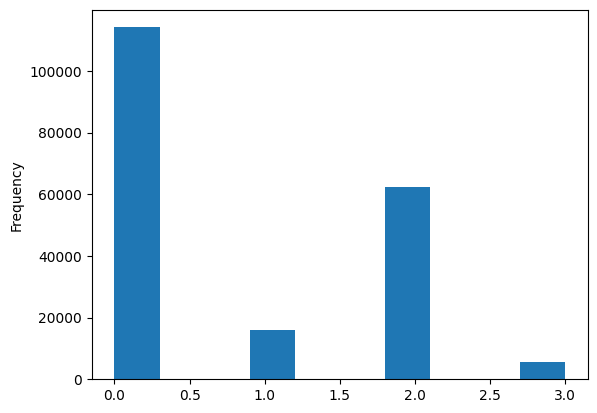

In [11]:
df['label'].plot(kind='hist')

#### Class Imbalance
Extreme imbalance in classes can be seen, which says "b" parameter in doc-len normalization will be a big contributor to model performance

### Data Preprocessing

In [12]:
stop_words = stopwords.words('english')

In [13]:
def clean_text(text):
    text = str(text).lower()
    text = str(text).translate(str.maketrans(string.punctuation,' '*len(string.punctuation)))
    text = str(text).translate(str.maketrans('','', string.digits))    
    text = text.split()
    text = " ".join([stem(i) for i in text]) # if len(i)>2 and len(i)<15]  #  if i not in stop_words
    return text


In [14]:
# Dropping Unnecessary columns, and rows
df = df.drop(['post_id', 'created_date', 'if_1', 'if_2'], axis=1)
df = df.drop(df[df['comment'].isnull()].index).reset_index(drop=True)

In [15]:
(df=='none').sum()

emoticon_1        0
emoticon_2        0
emoticon_3        0
upvote            0
downvote          0
race          39681
religion      38248
gender        36160
disability        0
comment           0
label             0
dtype: int64

In [16]:
# Replacing 'none' with nan
df = df.replace('none','')
df[['race', 'religion', 'gender']] = df[['race', 'religion', 'gender']].replace(np.nan,'')

In [17]:
df.isna().sum()

emoticon_1    0
emoticon_2    0
emoticon_3    0
upvote        0
downvote      0
race          0
religion      0
gender        0
disability    0
comment       0
label         0
dtype: int64

In [18]:
# Adding column values to the comment
df['comment'] = df['comment'] + df[['race', 'religion', 'gender']].apply(lambda x: ' '.join(x), axis=1)

In [19]:
# Adding the word 'disability' to the comment where column disability has value True, as this will be incorporated as a feature in vectorization Step
df.loc[df['disability'],'comment'] = df.loc[df['disability'],'comment'] + ' disability'

In [20]:
df = df.drop(['race', 'religion', 'gender', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'disability'], axis=1)

In [21]:
train_df, val_df = train_test_split(df, test_size=.2, stratify=df['label'], random_state=42)

In [22]:
vec = TfidfVectorizer(preprocessor=clean_text, ngram_range=(1,2), max_features=50000)

In [23]:
vec.fit(train_df['comment'])

TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                preprocessor=<function clean_text at 0x00000224C0F47C10>)

In [ ]:
train_df['']

In [24]:
train_m = vec.transform(train_df['comment'])

In [57]:
train_m = hstack([train_m,csr_matrix(train_df[['upvote', 'downvote']].values)])


In [ ]:
val_m = vec.transform(val_df['comment'])
val_m = hstack([val_m,csr_matrix(val_df[['upvote', 'downvote']].values)])

In [26]:
from sklearn.ensemble import GradientBoostingClassifier

In [27]:
clf = GradientBoostingClassifier(n_estimators=20)

In [28]:
clf.fit(train_m, train_df['label'])

GradientBoostingClassifier(n_estimators=20)

In [29]:
y_pred = clf.predict(val_m)

In [30]:
confusion_matrix(val_df['label'], y_pred)

array([[21944,   357,   501,    32],
       [ 1399,  1701,    75,     9],
       [ 8804,   344,  3321,    19],
       [  936,    35,     8,   115]])

In [31]:
accuracy_score(val_df['label'], y_pred)

0.6838636363636363

In [ ]:
from sklearn.neural_network import MLPClassifier


In [ ]:
clf2 = MLPClassifier((32, 64), verbose=True, max_iter=10)
clf2.fit(train_m, train_df['label'])

In [60]:
y_pred2 = clf2.predict(val_m)


In [61]:
confusion_matrix(val_df['label'], y_pred2)

array([[18482,   705,  3378,   269],
       [  780,  1914,   427,    63],
       [ 3404,   497,  8475,   112],
       [  466,    55,   143,   430]])

In [62]:
accuracy_score(val_df['label'], y_pred2)

0.7399242424242424